In [1]:
from dataclasses import dataclass

@dataclass
class RunLogs:
    algorithm: str
    num_nodes: int
    degree: int
    message_size: str
    header_label: str
    num_messages: int
    published_message_logs: list[dict]
    received_message_logs: list[dict]
    bandwidth_logs: list[dict]
    processed_chunks: list[dict]
    color: str



In [2]:
import matplotlib.colors as mcolors

colors = {
        "blue": ["#4f80bd", "#93c5fd", "#0284c7"],
        "red": ["#741b47", "#351c75"],
        "green": ["#38761d", "#93c47d"],
        "gray": ["#333333", "#444444"],
}



def lighten_color(hex_color, amount=0.5):
    """
    Lighten a hex color by blending with white.
    amount=0 returns original color, amount=1 returns white.
    """
    # Convert hex to RGB
    rgb = mcolors.hex2color(hex_color)
    # Blend with white
    lightened = tuple(c + (1 - c) * amount for c in rgb)
    return mcolors.to_hex(lightened)

In [3]:
from datetime import datetime
import re

def split_logfmt(s):
    return re.findall(r'\S+="[^"]*"|\S+', s)

def parse_log_line(line):
    return dict(x.split("=", 1) for x in split_logfmt(line))

def typecast_log_line(x):
    x = {k: int(v) if k in {'at', 'node-num', 'count', 'elapsed', 'sentbps', 'receivedbps', 'unused', 'new', 'repeat'} else v
            for k, v in x.items()}
    if 'time' in x:
        x['time'] = datetime.fromisoformat(x['time'])
    return x

def add_delta_at(logs, published_message_logs, *, should_round=False, interval_ms=100):
    res = []
    i = 0
    if len(logs) == 0 or len(published_message_logs) == 0:
        return []

    # use the message-id field to identify the corresponding message if present
    if 'message-id' in logs[0]:
        publish_time = {x['message-id']: x['at'] for x in published_message_logs}
        for d in logs:
            if d['message-id'] in publish_time:
                d['delta_at'] = d['at'] - publish_time[d['message-id']]
                res.append(d)
        return res

    # otherwise, find the closest message publish time
    for d in logs:
        while i < len(published_message_logs) and published_message_logs[i]['at'] < d['at']:
            i += 1
        # i is at the next message or len(published_message_logs)
        if i == 0:
            continue
        d['message-id'] = published_message_logs[i-1]['message-id']
        d['delta_at'] = d['at'] - published_message_logs[i-1]['at']
        res.append(d)
    res = [d for d in res if d.get('message-id', None)]
    if should_round:
        for d in res:
            d['at'] = (d['at']//interval_ms)*interval_ms
            d['delta_at'] = (d['delta_at']//interval_ms)*interval_ms
    return res

def parse_and_typecast_logs(lines, filter, published_message_logs, *, should_round=False, interval_ms=100):
    logs = [parse_log_line(line) for line in lines if filter in line]
    logs = [typecast_log_line(x) for x in logs]
    logs = sorted(logs, key=lambda x: x['at']) 
    return add_delta_at(logs, published_message_logs, should_round=should_round, interval_ms=interval_ms)

def get_published_message_logs(lines):
    logs = [parse_log_line(line) for line in lines if "Published Message" in line]
    logs = [typecast_log_line(x) for x in logs]
    return sorted(logs, key=lambda x: x['at'])

def get_received_message_logs(lines, published_message_logs):
    return parse_and_typecast_logs(lines, "Received Message", published_message_logs)

def get_bandwidth_logs(lines, published_message_logs, interval_ms):
    return parse_and_typecast_logs(lines, "bandwidth usage", published_message_logs, should_round=True, interval_ms=interval_ms)

def get_processed_chunks_logs(lines, published_message_logs):
    return parse_and_typecast_logs(lines, "chunk received", published_message_logs)

def parse_log_lines_simnet(lines, interval_ms):
    published_message_logs = get_published_message_logs(lines)
    received_message_logs = get_received_message_logs(lines, published_message_logs)
    bandwidth_logs = get_bandwidth_logs(lines, published_message_logs, interval_ms)
    processed_chunks_logs = get_processed_chunks_logs(lines, published_message_logs)
    return published_message_logs, received_message_logs, bandwidth_logs, processed_chunks_logs

In [4]:
from pathlib import Path

def parse_shadow_run(shadow_run_dir):
    """
    Parse a shadow run directory and extract message latencies.
    """
    shadow_run_dir = Path(shadow_run_dir)
    hosts_dir = shadow_run_dir / "shadow.data" / "hosts"
    if not hosts_dir.exists():
        print(f"no directory found: {hosts_dir}")
        return None
    
    interval_ms = 100

    received_message_logs = []
    bandwidth_logs = []
    processed_chunks_logs = []
    
    # Parse node0 to get publish times - try both possible stderr filenames
    node0_stderr = hosts_dir / "node0" / "simnode.1000.stderr"
    if not node0_stderr.exists():
        node0_stderr = hosts_dir / "node0" / "main.1000.stderr"
    if not node0_stderr.exists():
        print(f"no stderr file found in {hosts_dir / 'node0'}")
        return None
    with open(node0_stderr, "r") as f:
        lines = f.readlines()
        published_message_logs = get_published_message_logs(lines)
    
    # Parse all other nodes for received times
    for node_dir in sorted(hosts_dir.iterdir()):
        if not node_dir.is_dir() or node_dir.name == "node0":
            continue
        # Try both possible stderr filenames
        stderr_file = node_dir / "simnode.1000.stderr"
        if not stderr_file.exists():
            stderr_file = node_dir / "main.1000.stderr"
        if not stderr_file.exists():
            continue
        with open(stderr_file, "r") as f:
            lines = f.readlines()
            received_message_logs.extend(get_received_message_logs(lines, published_message_logs))
            bandwidth_logs.extend(get_bandwidth_logs(lines, published_message_logs, interval_ms))
            processed_chunks_logs.extend(get_processed_chunks_logs(lines, published_message_logs))

    return published_message_logs, received_message_logs, bandwidth_logs, processed_chunks_logs



In [5]:
experiment_dir = "/tmp/exp-200/exp-20260205-195416-183-e1523d-algorithm-comparison"

# Parse RLNC run
pl, rl, bl, cl = parse_shadow_run(f"{experiment_dir}/runs/RLNC-nc16-bm0-t100")
plg, rlg, blg, clg = parse_shadow_run(f"{experiment_dir}/runs/gossipsub")

In [6]:
import numpy as np

msg_logs = { x['message-id']: [] for x in bl}
for x in bl:
        msg_logs[x['message-id']].append(x['delta_at'])
for k, v in msg_logs.items():
        print("rlnc", k, min(v), max(v))


msg_logs = { x['message-id']: [] for x in blg}
for x in blg:
        msg_logs[x['message-id']].append(x['delta_at'])
for k, v in msg_logs.items():
        print("gossipsub", k, min(v), np.mean(v))

rlnc msg-0 0 1000
rlnc msg-1 0 1000
rlnc msg-2 0 1000
rlnc msg-3 0 1000
rlnc msg-4 0 10300
gossipsub msg-0 0 14812.492384549774
gossipsub msg-1 0 14598.861773811692
gossipsub msg-2 0 14561.088193670772
gossipsub msg-3 0 14639.134360703107
gossipsub msg-4 0 4938.114300315135


In [7]:
import statistics 

def compute_stats(latencies):
    """
    Compute statistics for a list of latency values.
    Assumes latencies are already sorted.
    """
    if not latencies:
        return {}

    n = len(latencies)

    return {
        "count": n,
        "min": min(latencies),
        "max": max(latencies),
        "mean": statistics.mean(latencies),
        "median": statistics.median(latencies),
        "stdev": statistics.stdev(latencies) if n > 1 else 0,
        "p25": latencies[int(n * 0.25)],
        "p50": latencies[int(n * 0.50)],
        "p75": latencies[int(n * 0.75)],
        "p90": latencies[int(n * 0.90)],
        "p95": latencies[int(n * 0.95)],
        "p99": latencies[int(n * 0.99)] if n >= 100 else latencies[-1],
    }


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cdf(run_logs_list: RunLogs, *, right_lim=None, msg_id=None):
    _, ax = plt.subplots(figsize=(10, 6), dpi=300)

    for run_logs in run_logs_list:
        sorted_logs = sorted(run_logs.received_message_logs, key=lambda x: x['delta_at'])
        if msg_id:
            sorted_logs = [x for x in sorted_logs if x['message-id'] == msg_id]
        delta_at_values = np.array([log['delta_at'] for log in sorted_logs])
        cumulative = np.arange(1, len(delta_at_values) + 1) / len(delta_at_values)
        ax.plot(delta_at_values, cumulative, linewidth=2, label=run_logs.header_label, color=run_logs.color)
    
    nodes = run_logs_list[0].num_nodes 
    degree = run_logs_list[0].degree
    message_size = run_logs_list[0].message_size
    ax.set_xlim(left=0)
    if right_lim:
        ax.set_xlim(right=right_lim)
    ax.set_xlabel('Time since publish (ms)', fontsize=12)
    ax.set_ylabel('CDF', fontsize=12)
    ax.set_title('CDF of Message Reception Latency', fontsize=14, pad=35)
    ax.text(0.5, 1.02, f'nodes: {nodes} degree: {degree}  message_size: {message_size}', 
            fontsize=12, ha='center', va='bottom', transform=ax.transAxes)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Calculate percentiles for all algorithms and sort by P95
    algorithm_stats = []
    for run_logs in run_logs_list:
        sorted_logs = sorted(run_logs.received_message_logs, key=lambda x: x['delta_at'])
        delta_at_values = [log['delta_at'] for log in sorted_logs]
        n = len(delta_at_values)
        p25 = delta_at_values[int(n * 0.25)]
        p50 = delta_at_values[int(n * 0.50)]
        p90 = delta_at_values[int(n * 0.90)]
        p95 = delta_at_values[int(n * 0.95)]
        algorithm_stats.append((run_logs.algorithm, p25, p50, p90, p95))
    
    algorithm_stats.sort(key=lambda x: x[4])
    percentile_text = []
    percentile_text.append(
        f"{'Algorithm':<20} {'P25':>6} {'P50':>6} {'P90':>6} {'P95':>6}"
    )
    percentile_text.append("-" * 45)
    for algorithm, p25, p50, p90, p95 in algorithm_stats:
        percentile_text.append(
            f"{algorithm:<20} {p25:>6.0f} {p50:>6.0f} {p90:>6.0f} {p95:>6.0f}"
        )
    
    info_text = "\n".join(percentile_text)
    ax.text(
        0.98,
        0.02,
        info_text,
        transform=ax.transAxes,
        fontsize=9,
        ha="right",
        va="bottom",
        bbox=dict(
            boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9
        ),
        family="monospace",
    )
    
    plt.tight_layout()
    plt.show()

In [9]:
# Plot average bandwidth across all nodes over time
from collections import defaultdict
import matplotlib.pyplot as plt

def average_bandwidth_by_time_by_node(bandwidth_logs, bandwidth_field):
    node_by_time = defaultdict(dict)
    for b in bandwidth_logs:
        t = b['delta_at']
        n = b['node-num']
        if n not in node_by_time[t]:
            node_by_time[t][n] = []
        node_by_time[t][n].append(b[bandwidth_field])
    res = {t: {n: np.mean(node_by_time[t][n]) for n in node_by_time[t]} for t in node_by_time}
    return res

def plot_bandwidth_usage(run_logs_list: list[RunLogs], *, right_lim=None):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), dpi=300)
    
    # Add main title
    fig.suptitle('Bandwidth usage over time (Average Per Node)', fontsize=16, y=0.995)
    
    max_time_sent = 0
    max_time_received = 0
    
    for run_logs in run_logs_list:
        num_nodes = run_logs.num_nodes
        sent_by_time = average_bandwidth_by_time_by_node(run_logs.bandwidth_logs, 'sentbps')
        received_by_time = average_bandwidth_by_time_by_node(run_logs.bandwidth_logs, 'receivedbps')

        times = sorted(sent_by_time.keys())
        avg_sent = [sum(sent_by_time[t].values()) / num_nodes for t in times]
        avg_received = [sum(received_by_time[t].values()) / num_nodes for t in times]

        times_sec = [t / 1000 for t in times]
        avg_sent_mbps = [s / 1_000_000 for s in avg_sent]
        avg_received_mbps = [r / 1_000_000 for r in avg_received]

        # Find last non-zero sent bandwidth
        for i in range(len(avg_sent_mbps) - 1, -1, -1):
            if avg_sent_mbps[i] > 0.01:
                max_time_sent = max(max_time_sent, times_sec[i])
                break
        
        # Find last non-zero received bandwidth
        for i in range(len(avg_received_mbps) - 1, -1, -1):
            if avg_received_mbps[i] >0.01:
                max_time_received = max(max_time_received, times_sec[i])
                break

        # Create lighter shade color
        light_shade_color = lighten_color(run_logs.color, amount=0.7)

        # Plot sent bandwidth with very light shading
        ax1.fill_between(times_sec, avg_sent_mbps, alpha=0.1, color=light_shade_color)
        ax1.plot(times_sec, avg_sent_mbps, label=run_logs.header_label, linewidth=2, color=run_logs.color)
        
        # Plot received bandwidth with very light shading
        ax2.fill_between(times_sec, avg_received_mbps, alpha=0.15, color=light_shade_color)
        ax2.plot(times_sec, avg_received_mbps, label=run_logs.header_label, linewidth=2, color=run_logs.color)

    # Configure sent bandwidth graph
    ax1.set_xlabel('Time since publish (seconds)', fontsize=12)
    ax1.set_ylabel('Bandwidth (Mbps)', fontsize=12)
    ax1.set_title('Send Bandwidth', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(left=0)
    if max_time_sent > 0:
        ax1.set_xlim(right=max_time_sent * 1.05)  # Add 5% padding
    if right_lim:
        ax1.set_xlim(right=right_lim)
    # Configure received bandwidth graph
    ax2.set_xlabel('Time since publish (seconds)', fontsize=12)
    ax2.set_ylabel('Bandwidth (Mbps)', fontsize=12)
    ax2.set_title('Receive Bandwidth', fontsize=14)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(left=0)
    if max_time_received > 0:
        ax2.set_xlim(right=max_time_received * 1.05)  # Add 5% padding
    if right_lim:
        ax2.set_xlim(right=right_lim)

    plt.tight_layout()
    plt.show()

In [10]:
import matplotlib.pyplot as plt
from collections import defaultdict

def cummulative_sum_by_time(chunk_logs, fields, num_nodes):
    val_by_time = defaultdict(dict)

    # Detect format: new format has 'utility' field with string values
    use_utility_field = chunk_logs and 'utility' in chunk_logs[0]

    for c in chunk_logs:
        t = c['delta_at']
        if use_utility_field:
            utility = c.get('utility', '')
            for k in fields:
                if k not in val_by_time[t]:
                    val_by_time[t][k] = 0
                if utility == k:
                    val_by_time[t][k] += 1
        else:
            for k in fields:
                if k not in val_by_time[t]:
                    val_by_time[t][k] = 0
                val_by_time[t][k] += c[k]
    
    times = sorted(val_by_time.keys())
    val, val_new = defaultdict(int), defaultdict(list)
    for t in times:
        for k in fields:
            val[k] += val_by_time[t].get(k, 0)
            val_new[k].append(val[k]/(num_nodes))
    return times, val_new
    
def plot_chunk_statistics(run_logs_list: list[RunLogs]):
    num_plots = len(run_logs_list)
    fig, axes = plt.subplots(1, num_plots, figsize=(10* num_plots, 10), dpi=300)

    # Add main title
    fig.suptitle('Chunk Statistics over time (Average Per Node)', fontsize=16, y=0.98)

    if num_plots == 1:
        axes = [axes]

    all_plot_data = []
    global_max_y = 0

    for run_logs in run_logs_list:
        # ignore the publisher(node-num=0)
        chunk_logs = [x for x in run_logs.processed_chunks if x['node-num'] != 0]
        times, csums_by_time = cummulative_sum_by_time(chunk_logs, ['new', 'unused', 'repeat', 'prevented'], run_logs.num_nodes-1)
        # the statistics are for all messages; divide by num_messages to get the value per message
        msg_ids = set(c['message-id'] for c in chunk_logs)
        num_messages = len(msg_ids)
        new_times = [x / num_messages for x in csums_by_time['new']]
        repeat_times = [x / num_messages for x in csums_by_time['repeat']]
        unused_times = [x / num_messages for x in csums_by_time['unused']]
        prevented_times = [x / num_messages for x in csums_by_time['prevented']]
        times_sec = [t / 1000 for t in times]

        max_total = max(n + r + u + p for n, r, u, p in zip(new_times, repeat_times, unused_times, prevented_times))
        global_max_y = max(global_max_y, max_total)

        all_plot_data.append({
            'times_sec': times_sec,
            'new_times': new_times,
            'repeat_times': repeat_times,
            'unused_times': unused_times,
            'prevented_times': prevented_times,
            'run_logs': run_logs
        })

    for idx, plot_data in enumerate(all_plot_data):
        ax = axes[idx]
        times_sec = plot_data['times_sec']
        new_times = plot_data['new_times']
        repeat_times = plot_data['repeat_times']
        unused_times = plot_data['unused_times']
        prevented_times = plot_data['prevented_times']
        run_logs = plot_data['run_logs']

        # Create colors: new (runlog color), repeat (yellow), unused (lighter runlog color)
        new_color = run_logs.color
        repeat_color = '#FCD34D'  # yellow shade
        unused_color = lighten_color(run_logs.color, amount=0.5)
        prevented_color = lighten_color(run_logs.color, amount=0.8)

        new_fill_color = lighten_color(new_color, amount=0.3)
        repeat_fill_color = lighten_color(repeat_color, amount=0.3)
        unused_fill_color = lighten_color(unused_color, amount=0.3)
        prevented_fill_color = lighten_color(prevented_color, amount=0.3)
        ax.stackplot(times_sec, new_times, repeat_times, unused_times, prevented_times,
                    labels=['New', 'Repeat', 'Unused', 'Prevented'],
                    colors=[new_fill_color, repeat_fill_color, unused_fill_color, prevented_fill_color],
                    alpha=0.7)

        # Add boundary lines on top
        # Line at top of "new"
        ax.plot(times_sec, new_times, color=new_color, linewidth=1.5, alpha=0.9)
        
        # Line at top of "new + repeat"
        new_plus_repeat = [n + r for n, r in zip(new_times, repeat_times)]
        ax.plot(times_sec, new_plus_repeat, color=repeat_color, linewidth=1.5, alpha=0.9)
        
        # Line at top of "new + repeat + unused" (total)
        total = [n + r + u for n, r, u in zip(new_times, repeat_times, unused_times)]
        ax.plot(times_sec, total, color=unused_color, linewidth=1.5, alpha=0.9)

        # Set consistent y-axis limits for all subplots
        ax.set_ylim(0, global_max_y * 1.05)

        # Add final values as y-axis ticks
        final_new = new_times[-1] if new_times else 0
        final_repeat = repeat_times[-1] if repeat_times else 0
        final_unused = unused_times[-1] if unused_times else 0
        final_total = final_new + final_repeat + final_unused

        current_yticks = list(ax.get_yticks())
        final_values = [round(final_new, 1), round(final_new + final_repeat, 1), round(final_total, 1)]
        # Combine current ticks with final values and sort
        all_yticks = sorted(set(current_yticks + final_values))
        ax.set_yticks(all_yticks)

        ax.set_xlabel('Time since publish (seconds)', fontsize=12)
        ax.set_ylabel('Total Count', fontsize=12)
        ax.set_title(run_logs.header_label, fontsize=14)
        ax.legend(fontsize=10, loc='upper left')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [11]:
# Configure experiment directory here
experiment_dir = "/tmp/exp-200/exp-20260205-195416-183-e1523d-algorithm-comparison"

# Parse RS run
pl, rl, bl, cl = parse_shadow_run(f"{experiment_dir}/runs/RS-d16-p16-bm0-t100")
rs_local = RunLogs(
    algorithm="RS",
    num_nodes=200,
    degree=15,
    num_messages=5,
    message_size="100KB",
    header_label="RS(k=16, bitmaps=off)",
    published_message_logs=pl,
    received_message_logs=rl,
    bandwidth_logs=bl,
    processed_chunks=cl,
    color=colors["blue"][0]
)

# Parse RLNC run
pl, rl, bl, cl = parse_shadow_run(f"{experiment_dir}/runs/RLNC-nc16-bm0-t100")
rlnc_local = RunLogs(
    algorithm="RLNC",
    num_nodes=200,
    degree=15,
    num_messages=5,
    message_size="100KB",
    header_label="RLNC(k=16, bitmaps=off)",
    published_message_logs=pl,
    received_message_logs=rl,
    bandwidth_logs=bl,
    processed_chunks=cl,
    color=colors["red"][0]
)

# Parse gossipsub run
pl, rl, bl, cl = parse_shadow_run(f"{experiment_dir}/runs/gossipsub")
gossipsub_local = RunLogs(
    algorithm="GossipSub",
    num_nodes=200,
    degree=15,
    num_messages=5,
    message_size="100KB",
    header_label="GossipSub",
    published_message_logs=pl,
    received_message_logs=rl,
    bandwidth_logs=bl,
    processed_chunks=cl,
    color=colors["gray"][0]
)

print(f"RS: {len(rs_local.received_message_logs)} received messages")
print(f"RLNC: {len(rlnc_local.received_message_logs)} received messages")
print(f"GossipSub: {len(gossipsub_local.received_message_logs)} received messages")

RS: 995 received messages
RLNC: 995 received messages
GossipSub: 995 received messages


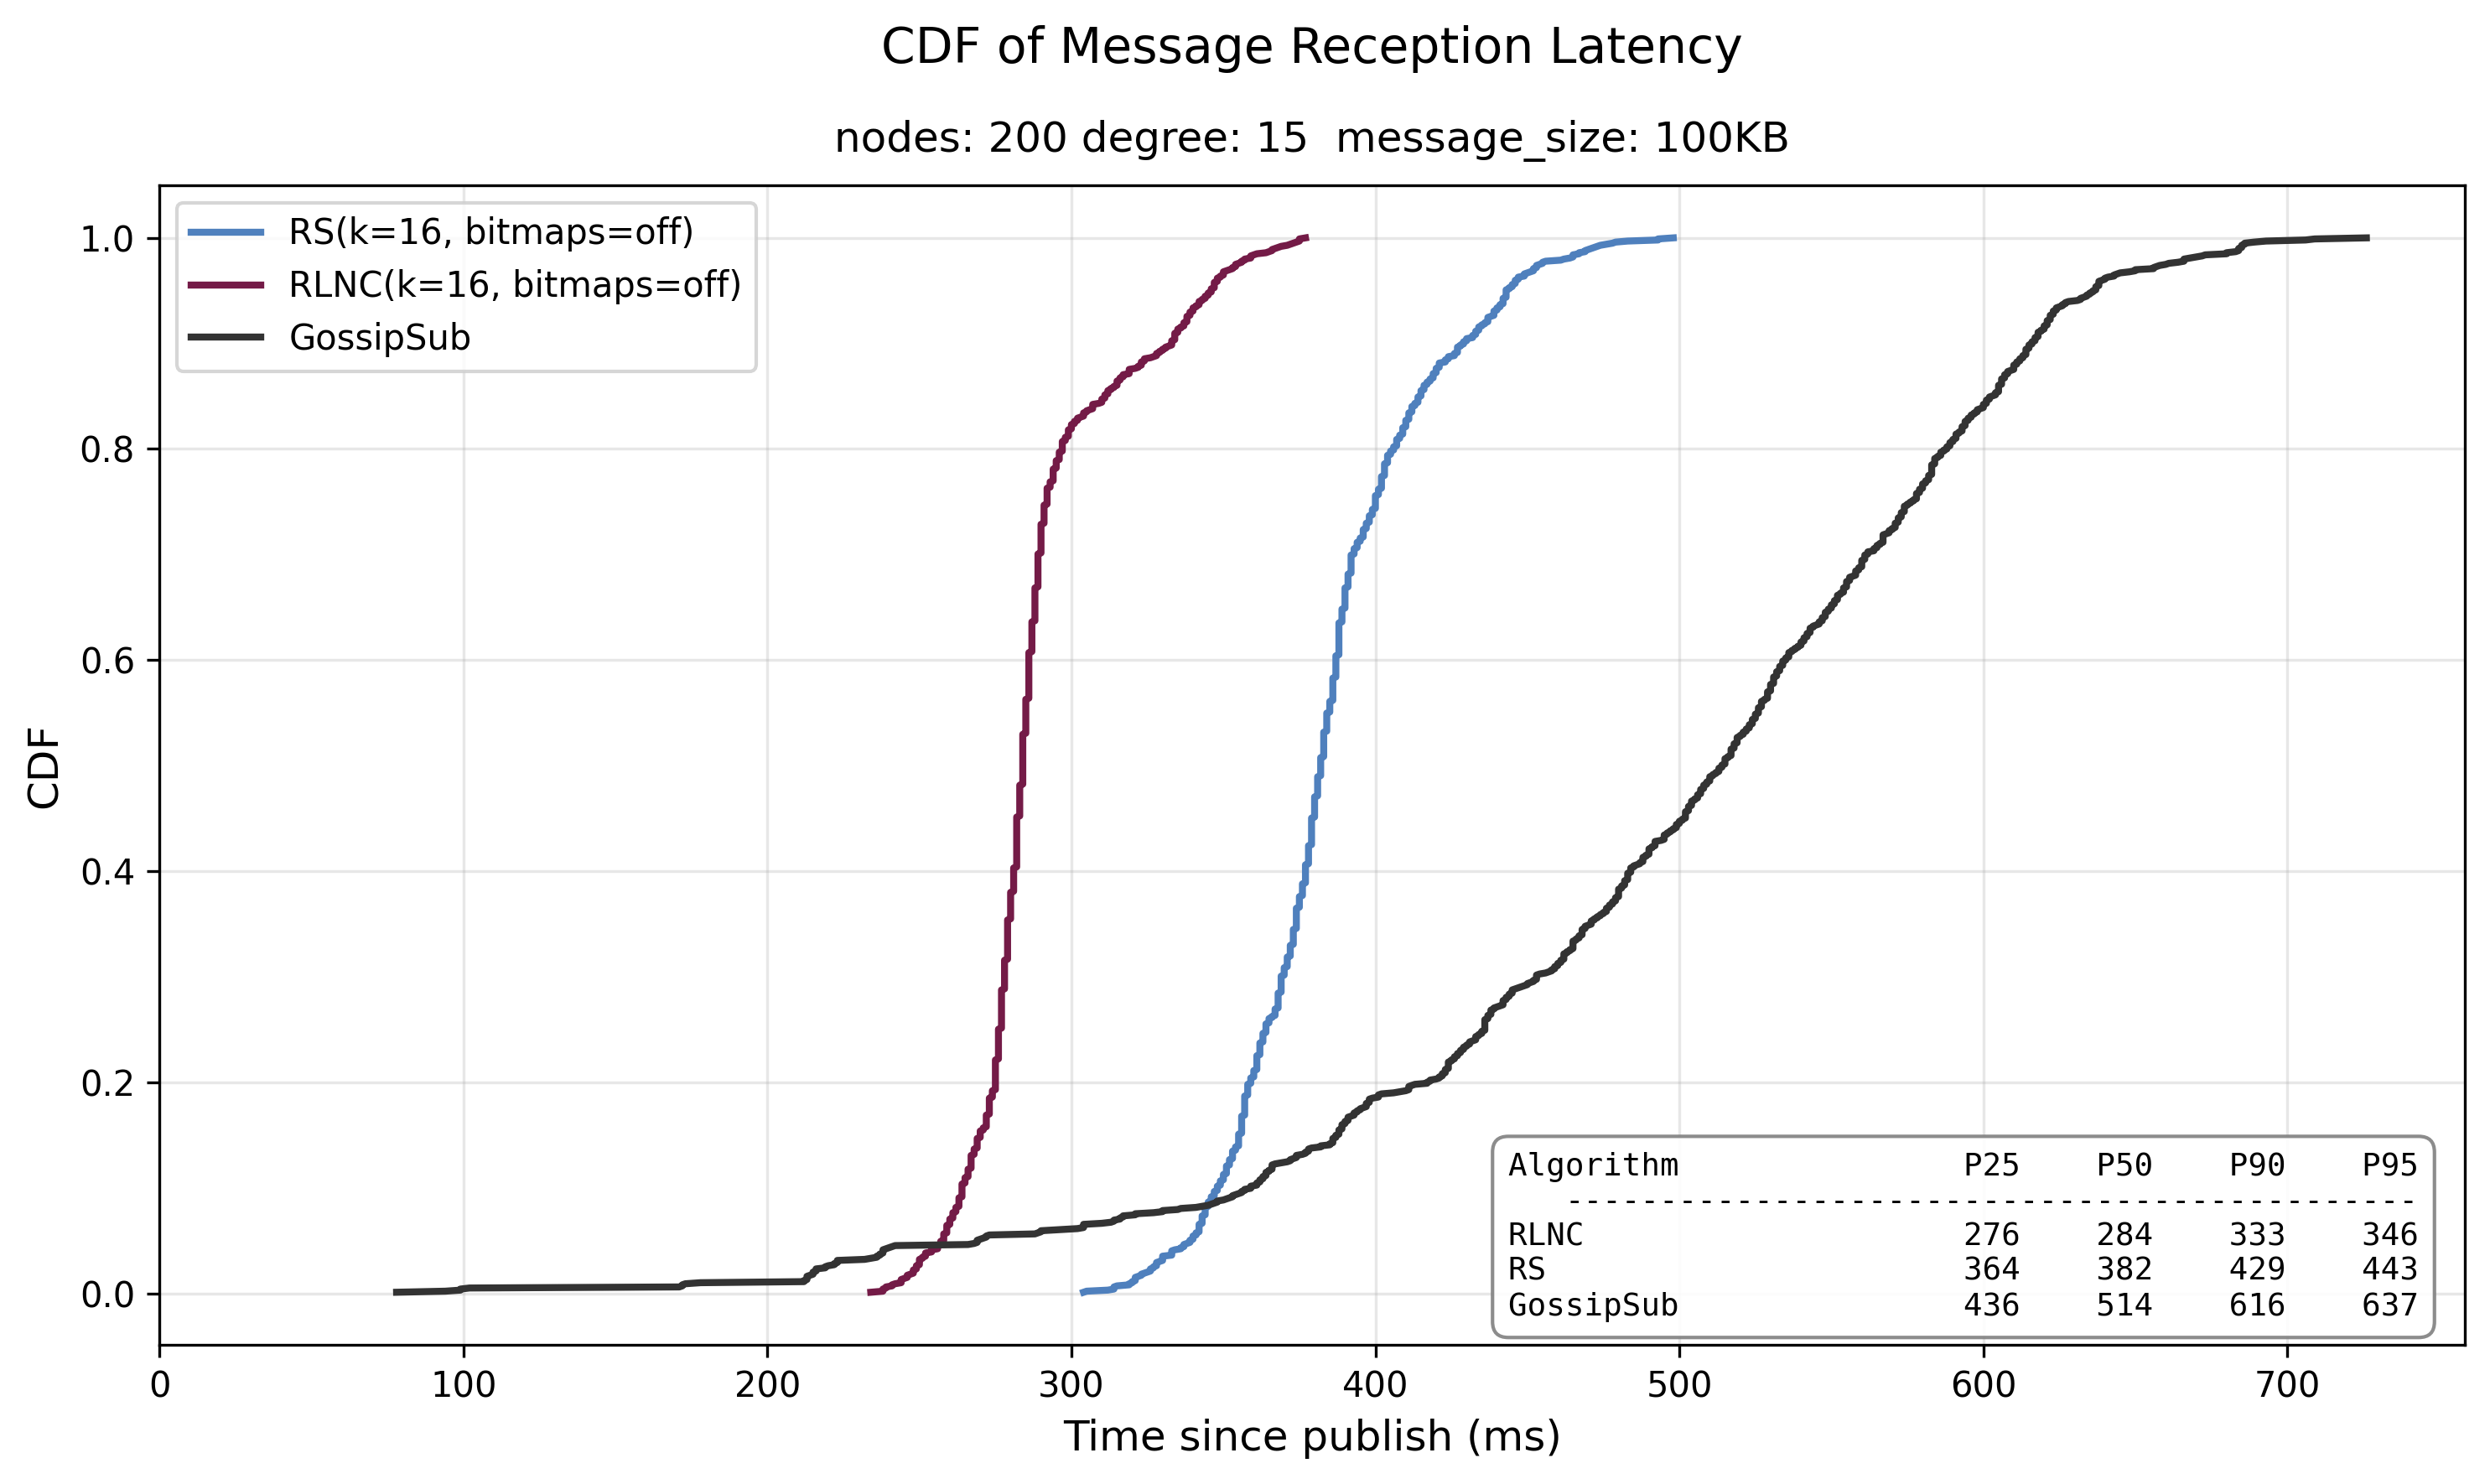

In [12]:
# Plot CDF of message reception latency
plot_cdf([rs_local, rlnc_local, gossipsub_local])

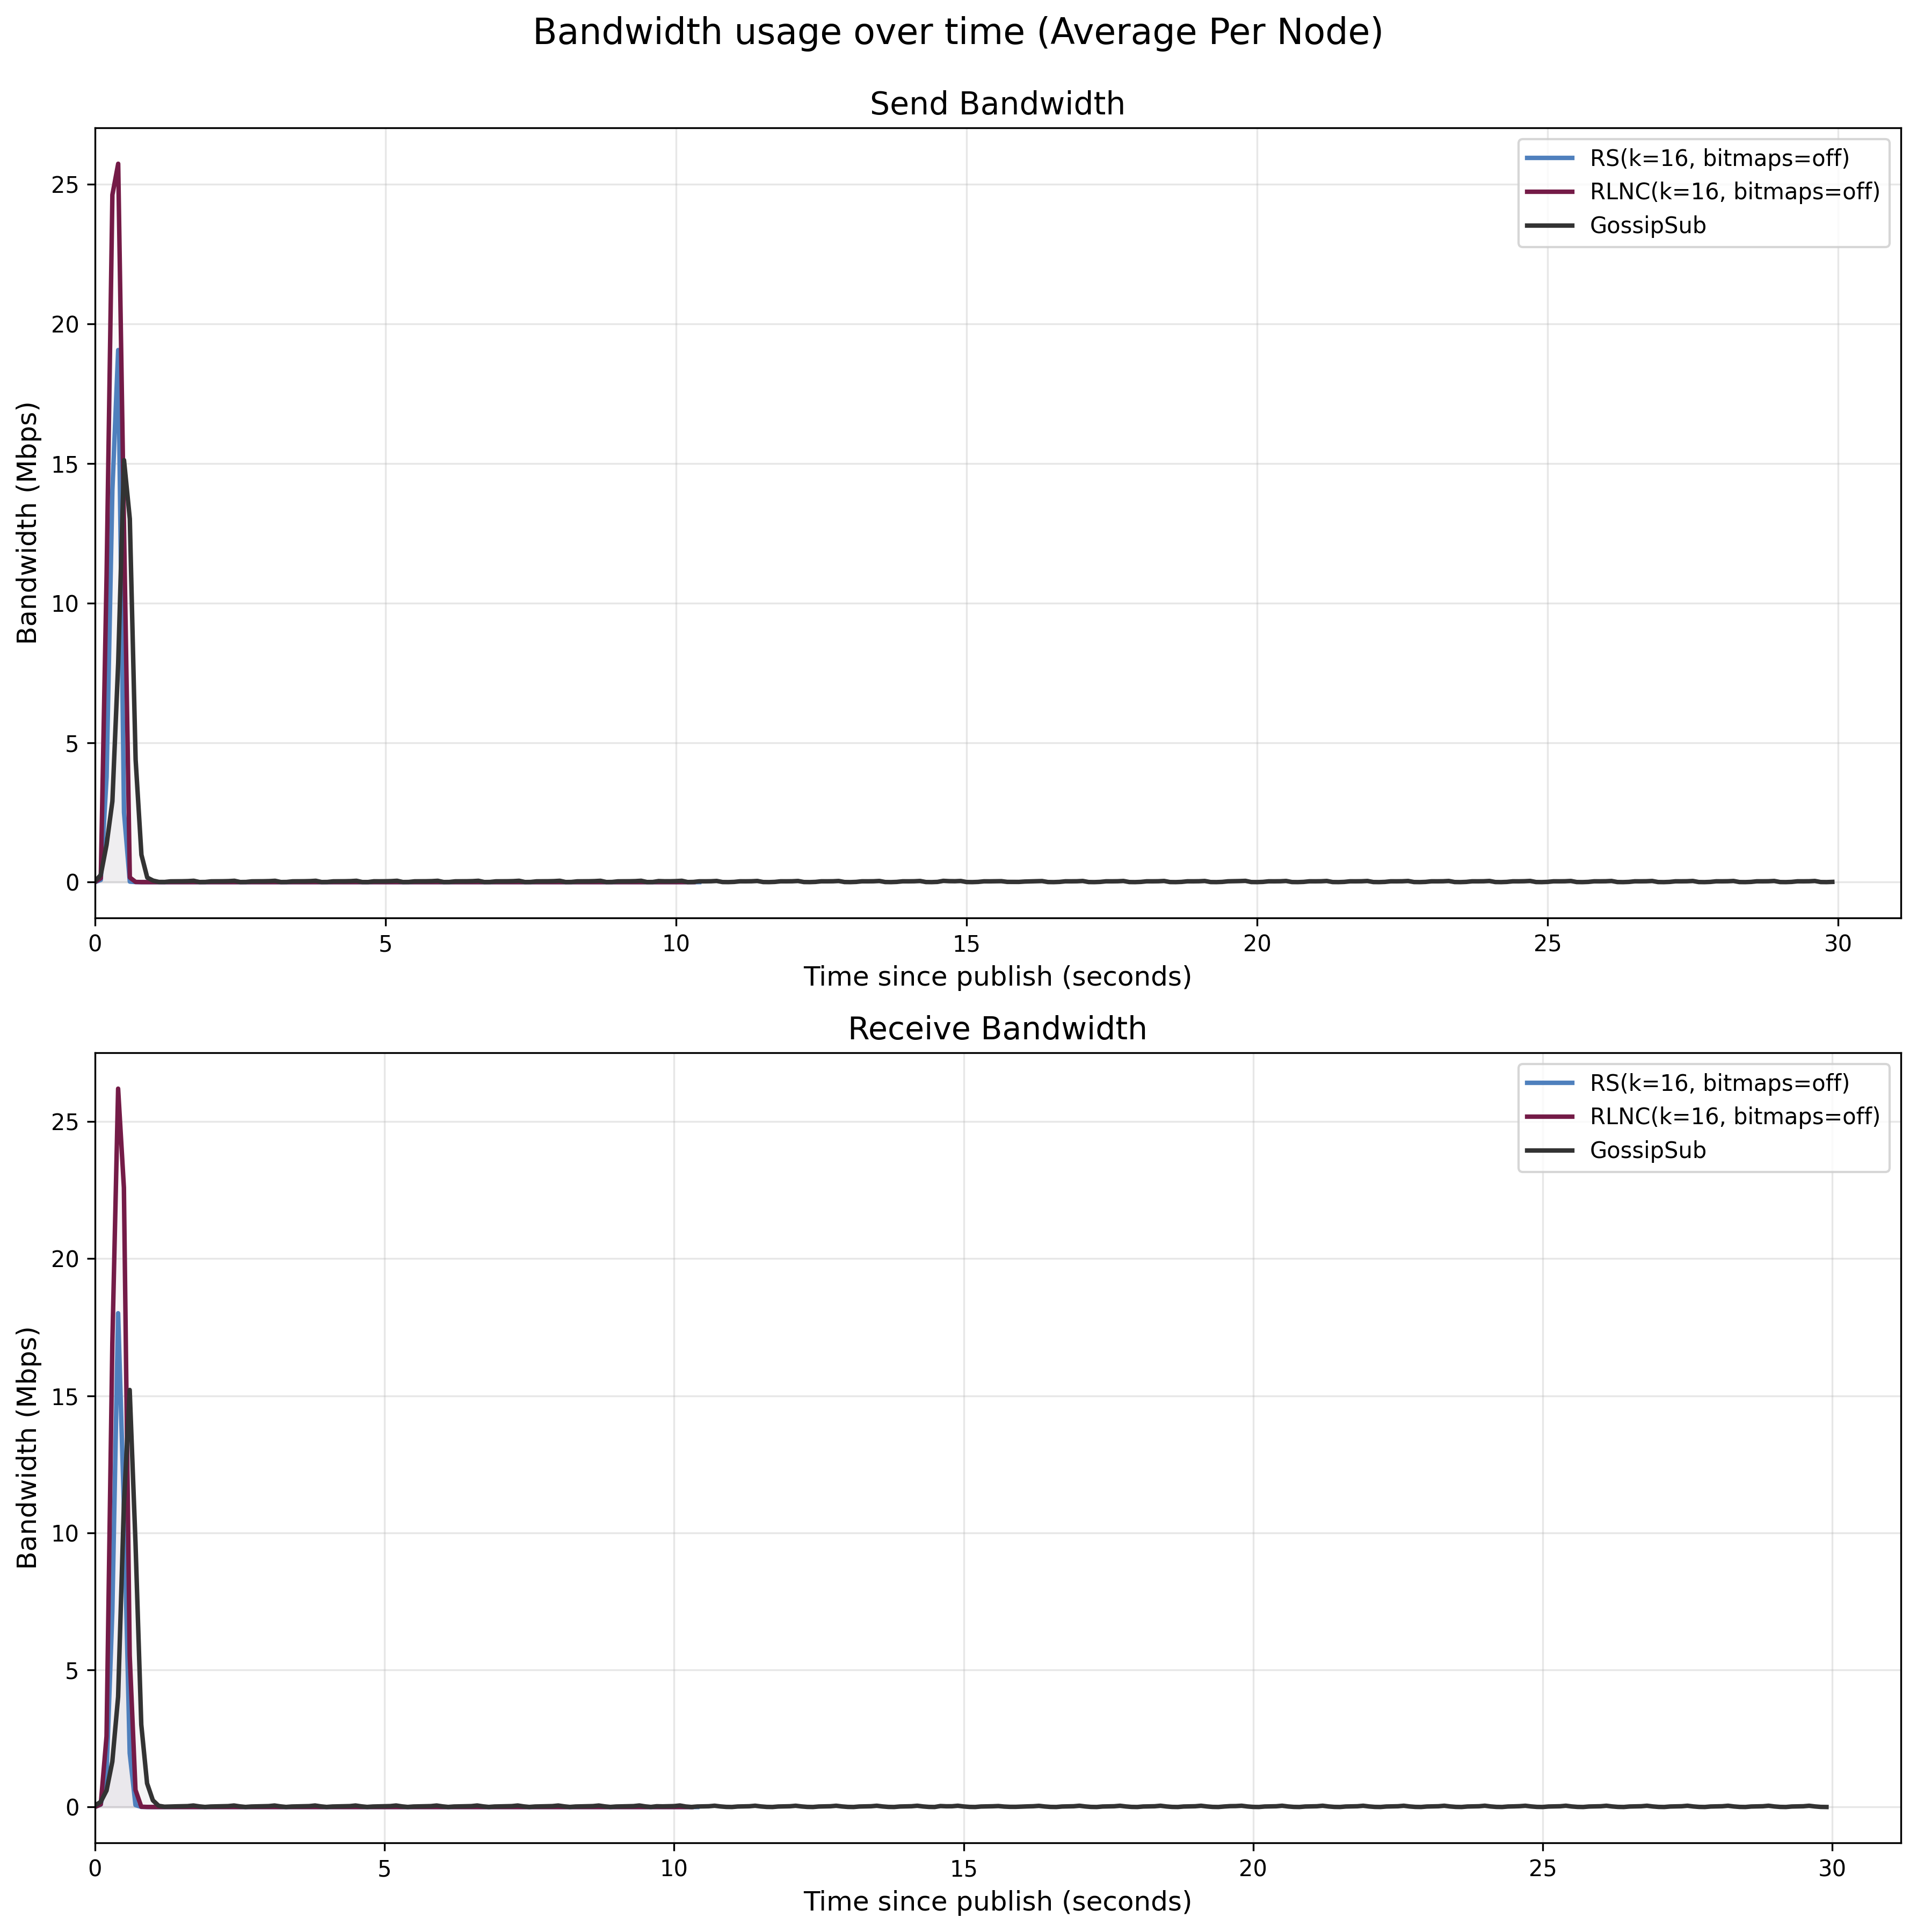

In [13]:
# Plot bandwidth usage over time
plot_bandwidth_usage([rs_local, rlnc_local, gossipsub_local])

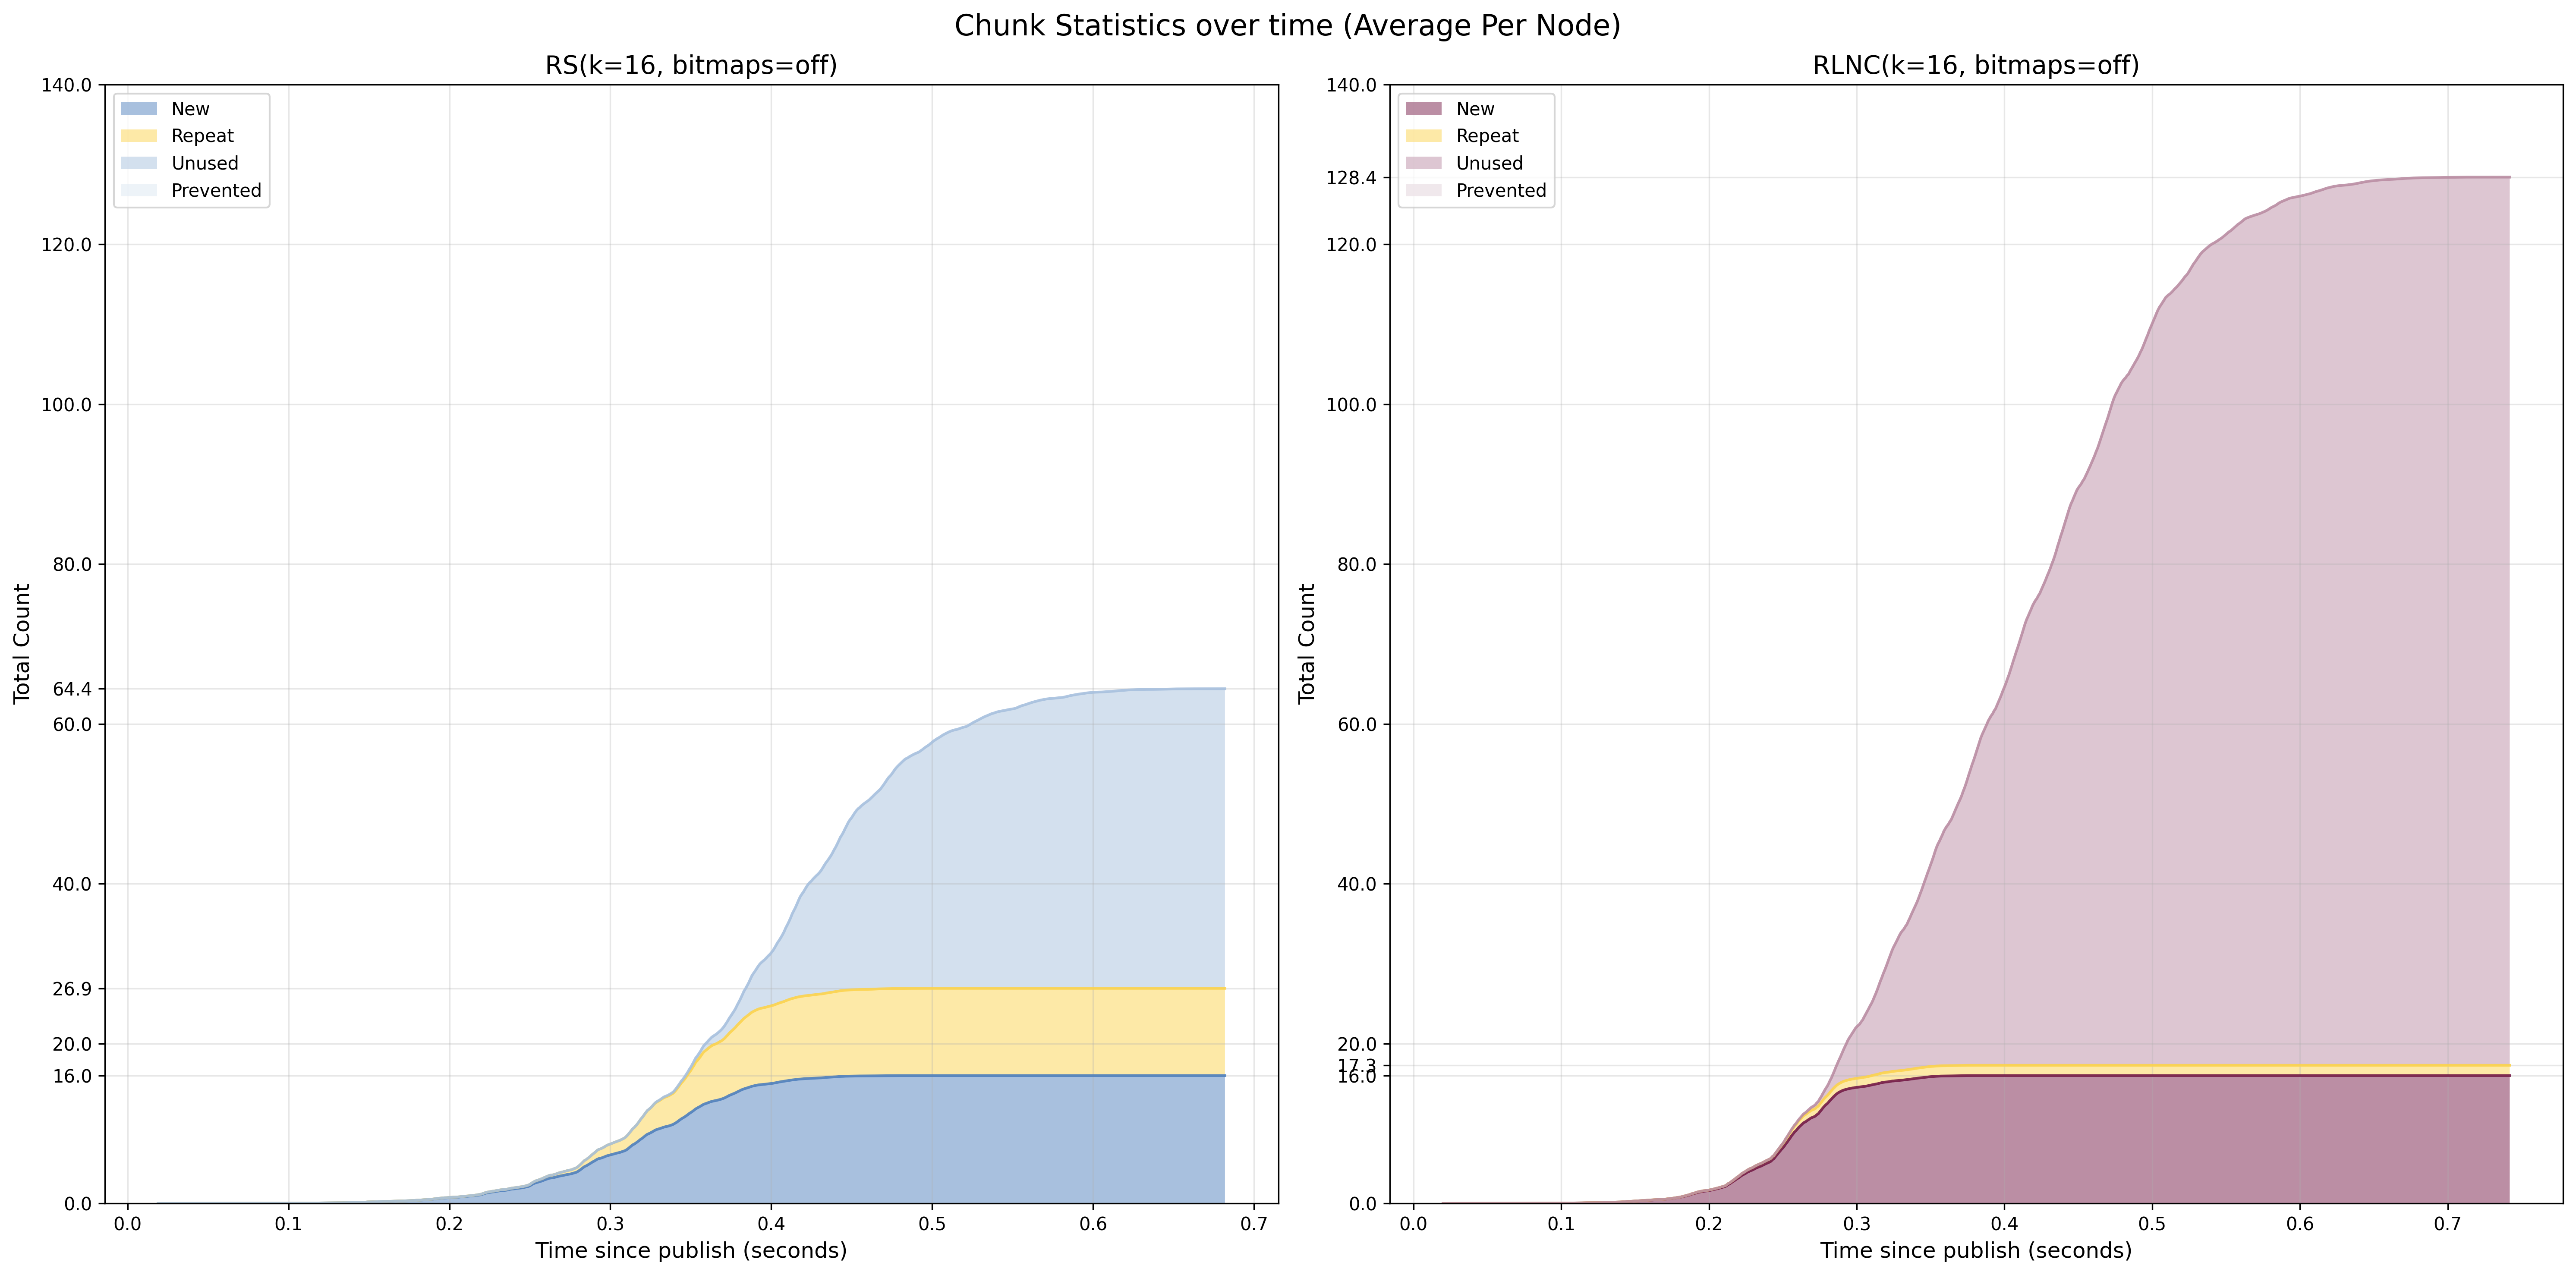

In [14]:
# Plot chunk statistics for RS and RLNC (gossipsub doesn't have chunk statistics)
plot_chunk_statistics([rs_local, rlnc_local])

In [15]:
# Print latency statistics summary
print("Latency Statistics (ms)")
print("=" * 60)

for run in [rs_local, rlnc_local, gossipsub_local]:
    latencies = sorted([x['delta_at'] for x in run.received_message_logs])
    stats = compute_stats(latencies)
    print(f"\n{run.algorithm}:")
    print(f"  Count: {stats['count']}")
    print(f"  Mean:  {stats['mean']:.1f} ms")
    print(f"  P50:   {stats['p50']:.1f} ms")
    print(f"  P90:   {stats['p90']:.1f} ms")
    print(f"  P95:   {stats['p95']:.1f} ms")
    print(f"  Max:   {stats['max']:.1f} ms")

Latency Statistics (ms)

RS:
  Count: 995
  Mean:  384.6 ms
  P50:   382.0 ms
  P90:   429.0 ms
  P95:   443.0 ms
  Max:   498.0 ms

RLNC:
  Count: 995
  Mean:  288.8 ms
  P50:   284.0 ms
  P90:   333.0 ms
  P95:   346.0 ms
  Max:   377.0 ms

GossipSub:
  Count: 995
  Mean:  495.4 ms
  P50:   514.0 ms
  P90:   616.0 ms
  P95:   637.0 ms
  Max:   726.0 ms
